<a href="https://colab.research.google.com/github/bandalyuli/first-repository/blob/master/%EA%B8%B0%EC%B4%88_%ED%86%B5%EA%B3%84_MainQuest03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

Using Colab cache for faster access to the 'online-retail' dataset.
Path to dataset files: /kaggle/input/online-retail


(541909, 8)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [7]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

/tmp/ipython-input-3844768752.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

In [8]:
sample_df = df.sample(n=1000, random_state=42)

In [9]:
#전체 데이터
population_mean = df["TotalPrice"].mean()
population_std = df['TotalPrice'].std()

#표본 데이터
sample_mean = sample_df['TotalPrice'].mean()
sample_std = sample_df['TotalPrice'].std()

result = pd.DataFrame({'구분': ['전체 데이터','표본(1000개)'],
                       '평균' : [population_mean, sample_mean],
                       '표준편차' : [population_std, sample_std]})

result

,구분,평균,표준편차
0,전체 데이터,17.987795,378.810824
1,표본(1000개),16.832070,64.467328


 모집단과 표본의 차이

평균 차이 : 약 1.16
표준편차 차이: 약 314.35  ---> 극단적으로 차이가 난다. 모집단에는 이상치가 있지만 표본에는 없어서 차이가 나는 것으로 추정됨


중심극한정리는 표본평균에 대한 정리로 표본평균의 분포가 모집단 평균을 중심으로 얼마나 퍼져있는지를 나타내는 척도


 모집단 평균: 17.99, 표본 평균: 16.83, 표본크기 n =1000

SE(표준오차) =  σ/루트 n = 378.81 / 루트 1000 ≈ 11.98

# 평균 차이(1.16)가 표준오차(11.98)에 비해 작은 차이라 이정도 차이는 자연스로운 변동이다.

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

In [10]:
#주문이 가장 많은 상위 국가
df['Country'].value_counts().head(2)

,count
Country,
United Kingdom,495478
Germany,9495


In [11]:
# t검정이용 두 국가간 'TotalPrice' 평균의 차이가 통계적으로 유의미 여부
# 이표본 t검정
from scipy.stats import ttest_ind


country_a = df[df['Country'] == 'United Kingdom']['TotalPrice']
country_b = df[df['Country'] == 'Germany']['TotalPrice']


t_stat, p_value = ttest_ind(country_a, country_b, equal_var=False)

t_stat, p_value



(np.float64(-10.046360185819829), np.float64(9.823416115791871e-24))

귀무가설: 두 국가간의 'TotalPrice' 평균의 차이가 같다


**t_stat = - 10.046**,
**p_value = 9.82e-24**

보통 유의수준은 α = 0.05

현재 p값으로 봤을 때

    **9.82e-24 ≪ 0.05**

즉, 0에 가까운 값으로 귀무가설을 강하게 기각하며, 이는 두 국가간 평균 차이는 통계적으로 매우 유의미하다

t_stat= - 10.046

t값이 음수인 경우 영국 평균이 독일 평균보다 작다.


귀무가설을 기각했는데 이 판단이 틀렸다면 1종 오류를 하게 된다. 하지만 p-값이 p_value = 9.82e-24이고 차이가 없는데 이런 결과가 나올확률이 극히 낮다.

그리고 2종 오류는 실제로 차이가 있는데 차이가 없다고 판단하는 것인데 귀무가설을 기각했기에 발생하지 않았다.


###독립표본 t-검정 결과 t = - 10.05, p < 0.001로 나타나, 두 국가 간의 'TotalPrice' 평균 차이는 통계적으로 유의미한 것으로 판단되었다. 이는 평균 차이가 표본 오차에 비해 매우 크다는 것을 말하며 귀무가설을 기각할 충분한 근거가 된다. 결과에서 귀무가설이 맞으면서도 기각할 확률은 극히 낮으며, 귀무가설을 기각하지 못하는 2종 오류는 발생하지 않았다. 그리고 영국의 평균 'TotalPrice'이 독일보다 낮았다.



## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

In [12]:
# 주중/ 주말 구분 기준
# 0 = 월요일... 4 = 금요일 -> 주중
# 5 = 토요일, 6 = 일요일 -> 주말

df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekday' if x < 5 else 'Weekend')

# 데이터 분리
weekday = df[df['DayType'] == 'Weekday']['UnitPrice']
weekend = df[df['DayType'] == 'Weekend']['UnitPrice']

In [13]:
#중심경향치: 평균, 중간값
#변산성: 표준편차, 분산
#분위수: 25%, 50%, 75%

unitPrice_stats = df.groupby('DayType')['UnitPrice'].agg(mean = 'mean', median = 'median', std = 'std', var = 'var')

unitPrice_stats


unitprice_quantiles = df.groupby('DayType')['UnitPrice'].quantile([0.25, 0.5, 0.75]).unstack()

unitprice_quantiles


,0.25,0.50,0.75
DayType,,,
Weekday,1.25,2.10,4.13
Weekend,1.25,1.85,3.75


/tmp/ipython-input-496837583.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday, weekend], labels=['weekday','weekend'])


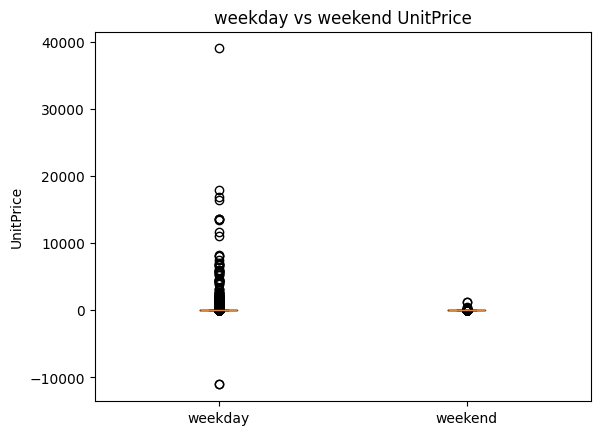

In [14]:
#상자수염그림과 히스토그램 시각화
#상자수염그림
plt.figure()
plt.boxplot([weekday, weekend], labels=['weekday','weekend'])
plt.title('weekday vs weekend UnitPrice')
plt.ylabel('UnitPrice')
plt.show()


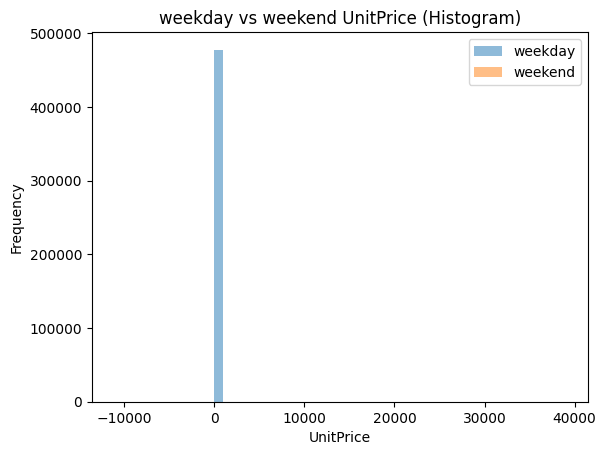

In [15]:
#히스토그램

plt.figure()
plt.hist(weekday, bins=50, alpha=0.5, label='weekday')
plt.hist(weekend, bins=50, alpha=0.5, label='weekend')
plt.legend()
plt.title('weekday vs weekend UnitPrice (Histogram)')
plt.xlabel('UnitPrice')
plt.ylabel('Frequency')
plt.show()



주중 평균 > 주말 평균
-> 주중에 상대적으로 고가 주문이 많음

평균과 중간값 차이가 큼
-> 분포가 오른쪽으로 치우침


주중 표준편차> 주말 표준편차
-> 주중 가격 변동성이 더 큼

주말 분산이 작음
-> 주말에는 가격대가 비교적 균일


분위수 관점
주중 75% 분위수가 주말보다 큼
-> 상위 가격대 상품이 주중에 더 자주 등장
중간값은 비슷하지만 상위 분위수 차이 큼
->극단값 차이가 평균 차이를 만듦


###상자수염그림과 히스토그램을 통해 확인한 결과, 주중의 UnitPrice 분포는 주말에 비해 중앙값과 상위 분위수가 더 높고, 이상치가 더 많이 관측된다. 반면 주말의 UnitPrice는 상대적으로 변동성이 작고 가격 분포가 집중되어 있다.





## 4. 상품의 단가와 판매 국가, 판매 날짜을 이용해 판매 수량을 예측하는 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
    * 종속변수: 판매 수량(`Quantity`)
    * 독립변수: 상품 단가(`UnitPrice`), 판매 국가(`Country`), 판매 요일(`DayOfWeek`), 판매 월( `InvoiceMonth`)   
* 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.

In [16]:
# 판매요일과 판매월은 초반에 작성되어 있음

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth,DayType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2,12,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2,12,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday


In [18]:
#분석에 필요한 컬럼만 선택
cols = ['Quantity', 'UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']
df_model = df[cols]

In [19]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Quantity      541909 non-null  int64  
 1   UnitPrice     541909 non-null  float64
 2   Country       541909 non-null  object 
 3   DayOfWeek     541909 non-null  int32  
 4   InvoiceMonth  541909 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(1)
memory usage: 16.5+ MB


In [20]:
# 결측치 제거
# 수량, 가격, 국가 중 하나라도 없으면 의미없는 행이며 회귀분석은 결측치 허용하지 않는다
# 분석에 필요한 컬럼 선택 후 정보를 확인했을 때 결측치가 없어서 코드는 작성했지만 실행하지는 않았다.

#df_model.isnull().sum()
#df_model = df_model.dropna()


In [21]:
df_model['Quantity'].sort_values()

,Quantity
540422,-80995
61624,-74215
225529,-9600
225530,-9600
4287,-9360
...,...
421632,4800
74614,5568
502122,12540
61619,74215


In [22]:
# 이상치 제거
df_model.describe()

# 판매수량 예측이라 반품이나 오류 제거하기
# Quantity	<= 0 제거
df_model = df_model[df_model['Quantity'] > 0 ]

# UnitPrice <= 0 제거 (반품으로 인한 금액)
df_model = df_model[df_model['UnitPrice'] > 0 ]

# 극단값 완화(IQR, 사분위간 범위)
  # 보통 IQR 1.5배 기준으로 '정상 범위' 설정, 이 범위 벗어나면 극단값으로 간주

df_model['Quantity'].sort_values()

  # 극단값 판별 기준
Q1 = df_model['Quantity'].quantile(0.25) # 최저 한계치
Q3 = df_model['Quantity'].quantile(0.75) # 최고 한계치
IQR = Q3 - Q1

  # 극단값 제거
df_model = df_model[(df_model['Quantity'] >= Q1 - 1.5 * IQR) &
                    (df_model['Quantity'] <= Q3 + 1.5 * IQR)]


In [23]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 473741 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Quantity      473741 non-null  int64  
 1   UnitPrice     473741 non-null  float64
 2   Country       473741 non-null  object 
 3   DayOfWeek     473741 non-null  int32  
 4   InvoiceMonth  473741 non-null  int32  
dtypes: float64(1), int32(2), int64(1), object(1)
memory usage: 18.1+ MB


In [24]:
# 원-핫 인코딩(범주형 변수 Coumtry)

df_model = pd.get_dummies(df_model, columns=['Country'], drop_first= True)



In [25]:
# 독립변수, 종속변수 설정
x = df_model.drop('Quantity', axis=1) # 종속변수에 영향을 준다고 가정하는 설명변수, 종속변수를 제외한 나머지 변수들로 설명하겠다
y = df_model['Quantity'] # 판매수량을 예측하고 싶기 때문에 예측 대상을 종속변수로 설정

# 다중 선형 회귀 모델 학습
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)


LinearRegression()

In [26]:
# 회귀계수 & 결정계수 확인

coef = pd.DataFrame(model.coef_, index=x.columns)
intercept = model.intercept_
r2 = model.score(x,y)

coef, intercept, r2




(                                     0
 UnitPrice                    -0.005203
 DayOfWeek                     0.003356
 InvoiceMonth                 -0.014432
 Country_Austria               0.744488
 Country_Bahrain              -1.873119
 Country_Belgium               0.384356
 Country_Brazil               -0.780104
 Country_Canada                1.017406
 Country_Channel Islands      -0.151832
 Country_Cyprus               -1.878371
 Country_Czech Republic        3.130703
 Country_Denmark               2.529209
 Country_EIRE                  0.157059
 Country_European Community   -1.008347
 Country_Finland               0.454627
 Country_France                0.534584
 Country_Germany               0.839174
 Country_Greece                1.199019
 Country_Hong Kong             0.813593
 Country_Iceland               1.279519
 Country_Israel               -0.517590
 Country_Italy                 0.137555
 Country_Japan                -2.358115
 Country_Lebanon               0.575603


회귀계수
UnitPrice 계수 = -0.005203
다른 조건이 동일할 때 상품 단가가 1 증가할 경우 평균 판매 수량이 약 0.005 감소한다. 일반적인 수요 법칙과 일치한다.

Country 계수
모든 Country 계수는 기준 국가(reference) 대비 차이. 더미에서 제외된 국가.
**같은 가격, 같은 시기라도, 나라에 따라 다르게 팔린다.**

기준 국가보다 많은 국가  Lithuania, Czech Republic, Singapore 등

기준 국가보다 적은 국가  United Kingdom, Unspecified, Japan 등


DayOfWeek 계수 =  0.003356
계수가 크다면 특정 요일 판매량 증가를 의미하지만 0에 가까운 작은 수라 요일 효과는 미미하다.

InvoiceMonth 계수 = -0.014432
뒤로 갈 수록 판매수량이 소폭 감소함
특정 시즌 효과 가능성이 있고 계절성은 있으나 강하지 않다


결정계수 R2 = 0.044
독립변수들이 판매수량 변동의 약 4.4%를 설명한다
이는 판매수량이 현재 독립 변수 이외에도 다양한 요인의 영향을 받기때문이라고 추정된다. 다만 주요 변수들의 회귀계수 방향성과 통계적 유의성을 통해 관계 분석에 의미가 있다.


###위의 회귀계수를 확인했을 때 판매 수량은 국가효과가 가장 크다.




## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [30]:
# 데이터 전처리
# 결측치 제거
df_modelr = df[['Quantity', 'UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']].dropna()

# 이상치 제거
# UnitPrice ≤ 0, Quantity = 0 은 의미 없음
df_modelr= df_modelr[(df_modelr['UnitPrice'] > 0 )& (df_modelr['Quantity'] != 0)]


In [33]:
# IsReturn 피쳐 생성
# 반품은 Quantity가 음수인 거래로 정의한다

df_modelr['IsReturn'] = df_modelr['Quantity'].apply(lambda x: 1 if x < 0 else 0)

# 피쳐 선택하기
# UnitPrice : 가격이 높을수록 반품 가능성 ↑
#Country : 국가별 반품 문화 차이
#DayOfWeek : 요일 효과
#InvoiceMonth : 시즌성

features = ['UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']
df_modelr = df_modelr[features + ['IsReturn']]

#원-핫 인코딩(범주형 변수)
df_modelr.info()
df_modelr = pd.get_dummies(df_modelr, columns=['Country'], drop_first= True)


<class 'pandas.core.frame.DataFrame'>
Index: 539392 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   UnitPrice     539392 non-null  float64
 1   Country       539392 non-null  object 
 2   DayOfWeek     539392 non-null  int32  
 3   InvoiceMonth  539392 non-null  int32  
 4   IsReturn      539392 non-null  int64  
dtypes: float64(1), int32(2), int64(1), object(1)
memory usage: 20.6+ MB


In [34]:
# x,y 설정

x = df_modelr.drop('IsReturn', axis= 1)
y = df_modelr['IsReturn']


# 데이터셋을 train셋과 test셋으로 나누기
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,  # 30% 를 테스트 데이터로 사용
    random_state=42  # 결과 재현을 위해 고정
    )

# 로지스틱 회귀 모델 학습

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)



LogisticRegression(max_iter=1000)

In [35]:
# 예측

y_pred = model.predict(x_test)


# 혼동행렬
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


# 정밀도 · 재현율 · F1-score

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           0       0.98      1.00      0.99    158976
           1       0.79      0.01      0.01      2842

    accuracy                           0.98    161818
   macro avg       0.89      0.50      0.50    161818
weighted avg       0.98      0.98      0.97    161818



정상거래인 클래스 0에서는 정밀도, 재현율, f1-score 이 높아 거의 완벽하게 맞춘다. 사실상 웬만하면 다 정상이라고 예측할게라는 말이다.

원래 예측하고자하는 반품거래인 클래스 1dms wogusdbfdl 0.01로 실제 반품에서 약 1%만 맞히고 99%는 놓쳤다. 반품을 거의 '정상'으로 판단함


데이터 분포가 정상(0)이 158,976, 반품(1)이 2,842로 반품 비율이 약 1.75%
weighted avg 의 f1-score = 0.97인 건 데이터가 많은 클래스(0)이 지배하기때문에 착시 효과가 발생한다.

그래서
###**현재 모델이 반품에 대한 재현율이 매우 낮아 실무에 적용하기 어렵다.**

모델 성능을 높이는 방법

1. 클래스 불균형 처리
2. 활률 기준 조정 등등



In [36]:
# 클래스 불균형 처리
LogisticRegression(class_weight='balanced')

# 확률 기준 조정
y_prob = model.predict_proba(x_test)[:, 1]
y_pred_custom = (y_prob > 0.3).astype(int)


